Importieren benötigter packages

In [30]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

print("Packages erfolgreich geladen.")

Packages erfolgreich geladen.


Verbindung zur Datenbank herstellen und aus der Rückgabe der SQL-Abfrage einen DataFrame erstellen.

Ziel der Abfrage: Identifikation von Messstellen mit vergleichsweise hohen Anteilen fehlender Messwerte. Das 90. Perzentil dient als Schwellenwert; dargestellt werden die zehn Messstellen mit den höchsten Fehlwertanteilen oberhalb dieses Schwellenwerts.

In [ ]:
conn = sqlite3.connect("Badegewaesser.db")

query = """ 
WITH anteile AS (
    SELECT
        MESSSTELLENID,
        MESSSTELLENNAME,
        COUNT(*) AS anzahl_proben,
        SUM(
            CASE WHEN ECOLI IS NULL THEN 1 ELSE 0 END
            + CASE WHEN INTEST_ENTEROKOKKEN IS NULL THEN 1 ELSE 0 END
            + CASE WHEN WASSERTEMP IS NULL THEN 1 ELSE 0 END
            + CASE WHEN LUFTTEMP IS NULL THEN 1 ELSE 0 END
            + CASE WHEN SICHTTIEFE IS NULL THEN 1 ELSE 0 END
        ) AS anzahl_fehlende_messwerte
    FROM messungen
    GROUP BY MESSSTELLENID, MESSSTELLENNAME
),

sortiert AS (
    SELECT
        MESSSTELLENID,
        MESSSTELLENNAME,
        anzahl_proben,
        anzahl_fehlende_messwerte,
        anzahl_fehlende_messwerte * 100.0 / (anzahl_proben * 5)
            AS anteil_fehlende_werte,
        ROW_NUMBER() OVER (
            ORDER BY
                anzahl_fehlende_messwerte * 100.0 / (anzahl_proben * 5)
        ) AS rang,
        COUNT(*) OVER () AS anzahl_stationen
    FROM anteile
),

position AS (
    SELECT
        CAST(0.90 * anzahl_stationen AS INTEGER)
        + CASE
            WHEN 0.90 * anzahl_stationen
                 > CAST(0.90 * anzahl_stationen AS INTEGER)
            THEN 1
            ELSE 0
          END AS perzentil_position
    FROM sortiert
    LIMIT 1
),

p90 AS (
    SELECT
        s.anteil_fehlende_werte
    FROM sortiert s
    CROSS JOIN position p
    WHERE s.rang = p.perzentil_position
)

SELECT
    s.MESSSTELLENID,
    s.MESSSTELLENNAME,
    s.anzahl_proben,
    s.anzahl_fehlende_messwerte,
    s.anteil_fehlende_werte
FROM sortiert s
CROSS JOIN p90
WHERE s.anteil_fehlende_werte > p90.anteil_fehlende_werte
ORDER BY s.anteil_fehlende_werte DESC
LIMIT 10
;
"""

df = pd.read_sql_query(query, conn)

conn.close()

print(df)

  MESSSTELLENID          MESSSTELLENNAME  anzahl_proben  \
0        0351_1                 SUEDDORF             20   
1        0337_1             WITTDUEN_OST             61   
2        0342_1          HUSUM;SCHOBUELL             41   
3        0338_1              HILLIGENLEY             15   
4        0339_1              BACKENSWARF             15   
5        0341_1               FUHLEHOERN             20   
6        0053_1            HOOGER FAEHRE            162   
7        0057_1  NORDS, HAMBURGER HALLIG             81   
8        0068_1               HOLMERSIEL             81   
9        0069_1            LUETTMOORSIEL             81   

   anzahl_fehlende_messwerte  anteil_fehlende_werte  
0                         20              20.000000  
1                         56              18.360656  
2                         36              17.560976  
3                         12              16.000000  
4                         12              16.000000  
5                         

Balkendiagramm zu den fehlenden Werten je Messstellen-ID erstellen

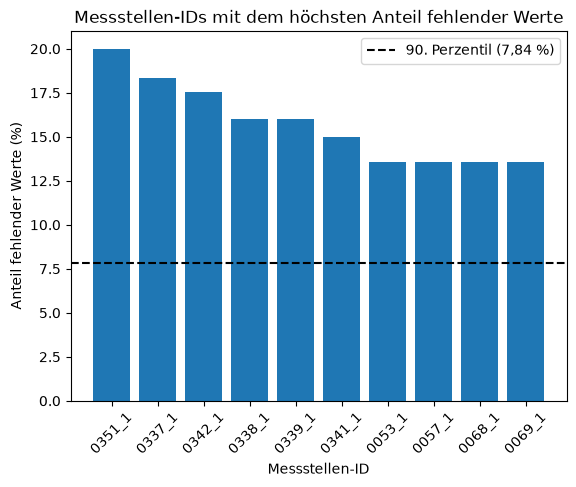

In [32]:
plt.bar(df.MESSSTELLENID, df.anteil_fehlende_werte)

plt.axhline(y=7.84, color="black", linestyle="--", label="90. Perzentil (7,84 %)")

plt.xlabel("Messstellen-ID")
plt.ylabel("Anteil fehlender Werte (%)")
plt.title("Messstellen-IDs mit dem höchsten Anteil fehlender Werte")

plt.xticks(rotation=45)

plt.legend()
